# FINA 4150 Quantitative Methods for Financial Derivatives
## Group (5?)
## Project 1: Step-Up Autocallable

CHOU, Chung Hei Johnny: [Sor I forgot]  
LAM, Yau Tsun:          [11551192467]  
LEUNG, Yuk Shing Cyrus: [1155193611]  
YAU, Tsz Lam:           [1155192228]  

```Things before you run:  
If you are using VS Code, look on top right and remember to select the right kernel!  
When u run the notebook u can select the kernel right, go and select a virtual environment and then VS code would make a terminal for u to install things through pip!  
Right now I am using a venv of python 3.14.  
And after you selected the right kernel, remember to pip install the right library that are required in the code.  
We should be using the latest libraries so no worries in the versions and all those but we will see haha.  

Other things to note:  
Everytime when u come back to the thing and try to work again: GIT PULL FIRST!
Everytime before you want to stage and commit things and git push all those: GIT PULL FIRST!
Everytime after you implemented anything: Stage and commit and GIT PUSH! Or else others may do ur stuff and when then u push itll become a fork.  
```

### Note for Keith:
- **AI Involvement**:  
  AI (Various LLMs in GitHub Copilot) is used only to aid on planning, and the framework of the code, all core logic are hand coded (For now). 

In [58]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import time
import scipy.optimize as optimize
import scipy.interpolate as interpolate
import warnings
import os
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
import datetime


## Market Data Classes

In [2]:
class Curves:
    """Store and retrieve time-dependent risk-free rates and dividend yield using cubic spline interpolation. Uses bootstrapping for instantaneous rates."""
    def __init__(self, x, y):
        self.cs = interpolate.CubicSpline(x, y)
        t = y.copy()
        for i in range(1, len(y)):
            # print(f"i = {i}")
            # print(f"Original y = {y[i]}, y diff = {y[i]-y[i-1]}, x diff = {x[i]-x[i-1]}")
            t[i] = ((1 + y[i]) ** x[i] / (1 + y[i-1]) ** x[i-1]) ** (1 / (x[i] - x[i-1])) - 1
            # print(f"Final y = {y[i]}")
        y = t
        self.cs_inst = interpolate.CubicSpline(x, y)
    
    def __call__(self, t: float) -> float: # This means when u make an object like rf = Curves(whatever), then you can just do rf(t) to get the interpolated value
        return self.cs(t)
    
    def instant(self, t: float) -> float: # Same as above but returns instantaneous rate
        return self.cs_inst(t)
    

In [98]:
warnings.filterwarnings("ignore")

class VolatilitySurface:
    def __init__(self, index_name: str, S0: float, r_curve, q_curve, files, mult = 1, folder: str = "."):
        self.index_name = index_name
        self.S0 = S0
        self.r_curve = r_curve
        self.q_curve = q_curve
        self.folder = folder
        self.mult = mult
        self.maturity_map = files
        self.T_list = []
        self.params = {}
        self._build_surface()

    def _implied_vol(self, S, K, T, price, Call: bool = True):
        r = self.r_curve(T)
        q = self.q_curve(T)
        def obj(sigma):
            if sigma <= 0: return 1e12
            sign = 1 + 2 * (Call - 1)
            d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
            d2 = d1 - sigma*np.sqrt(T)
            return (sign * S * np.exp(-q * T) * norm.cdf(sign * d1)) - (sign * K * np.exp(-r * T) * norm.cdf(sign * d2)) - price
        
        try:
            return optimize.brentq(obj, 1e-6, 10.0)
        except Exception:
            return np.nan

    def _build_surface(self):
        total_points = 0
        
        for (filename_call, filename_put), T in self.maturity_map.items():
            path_call = os.path.join(self.folder, filename_call)
            path_put = os.path.join(self.folder, filename_put)
            if not os.path.exists(path_call):
                print(f"Missing: {filename_call}")
                continue
            if not os.path.exists(path_put):
                print(f"Missing: {filename_put}")
                continue
                
            print(f"\nLoading {self.index_name:6} | {filename_call:25} | T = {T:.3f}y ... ", end="")
            print(f"\nLoading {self.index_name:6} | {filename_put:25} | T = {T:.3f}y ... ", end="")

            calls = pd.read_csv(path_call)
            puts  = pd.read_csv(path_put)

            data_list = []
            
            # OTM PUTS: K < S0 (left)
            for _, row in puts.iterrows():
                K = row['Strike']
                if K > self.S0: continue  # STRICT: Only true OTM puts
                bid = pd.to_numeric(row.get('Bid', np.nan), errors='coerce')
                ask = pd.to_numeric(row.get('Ask', np.nan), errors='coerce')
                last = pd.to_numeric(row.get('Last', np.nan), errors='coerce')
                mid = abs(0.5 * (bid + ask))
                price = np.nan
                if not np.isnan(bid) and not np.isnan(ask) and (bid > 0 and ask > 0) and abs((bid - ask) / mid) <= 0.1: # 0.1 as the threahold for acceptable bid-ask spread ratio
                    price = mid
                elif not np.isnan(last) and last > 0:
                    price = last

                price /= self.mult
                if not np.isnan(price) and price > 0:
                    data_list.append({'Strike': K, 'price': price, 'Call': False})

            # OTM CALLS: K > S0 (right)
            for _, row in calls.iterrows():
                K = row['Strike']
                if K < self.S0: continue  # STRICT: Only true OTM calls
                bid = pd.to_numeric(row.get('Bid', np.nan), errors='coerce')
                ask = pd.to_numeric(row.get('Ask', np.nan), errors='coerce')
                last = pd.to_numeric(row.get('Last', np.nan), errors='coerce')
                mid = abs(0.5 * (bid + ask))
                price = np.nan
                # Mid quote if both bid and ask are positive and not NaN
                if not np.isnan(bid) and not np.isnan(ask) and (bid > 0 and ask > 0) and abs((bid - ask) / mid) <= 0.1: # 0.1 as the threahold for acceptable bid-ask spread ratio
                    price = mid
                # Otherwise, use last if valid
                elif not np.isnan(last) and last > 0:
                    price = last

                price /= self.mult
                if not np.isnan(price) and price > 0:
                    data_list.append({'Strike': K, 'price': price, 'Call': True})
            
            data = pd.DataFrame(data_list)
            points = len(data)
            print(f"{points:5} points", end="")
            total_points += points
            
            if points < 10:
                print(" → skipped")
                continue
                
            log_m_list = []
            iv_list = []
            for _, row in data.iterrows():
                iv = self._implied_vol(self.S0, row['Strike'], T, row['price'], row['Call'])
                if np.isnan(iv) or iv < 0.05 or iv > 1.5:
                    continue
                log_m_list.append(np.log(row['Strike'] / (self.S0 * np.exp(self.r_curve(T) * T - self.q_curve(T) * T))))
                iv_list.append(iv)
            
            if len(iv_list) < 10:
                print(" → too few valid IVs")
                continue
                
            m_arr = np.array(log_m_list)
            iv_arr = np.array(iv_list)
            idx = np.argsort(m_arr)
            m_arr, iv_arr = m_arr[idx], iv_arr[idx]
            
            try:
                p0 = [np.median(iv_arr), 0.10, 12.0, 0.1, 0.1]
                popt, _ = optimize.curve_fit(
                    lambda m, a, c, d, e, f: a + c * (np.tanh(d * m)/d) + e * (np.tanh(f * m) /f) ** 2,
                    m_arr, iv_arr, p0=p0, maxfev=50000,
                    bounds=([0.01, -1, 0, 0.01, 0.00], [1.0, 1.0, 40, 4.0, 1.0])
                )
                self.params[T] = popt.tolist()
                self.T_list.append(T)
                print(f" → FITTED ATM {popt[0]:.2%} | skew {popt[1]:.3f}")
            except Exception as e:
                print(f" → fit failed: {e}")
        
        self.T_list = sorted(self.T_list)
        print(f"\n{self.index_name} SURFACE READY — {len(self.T_list)} maturities, {total_points} OTM points\n")

    def _interp_params(self, t):
        if not self.T_list:
            return [0.25, 0.08, -10.0, 0.05]  # Default parameters if no data available
        if t <= self.T_list[0]: return self.params[self.T_list[0]]
        if t >= self.T_list[-1]: return self.params[self.T_list[-1]]
        i = np.searchsorted(self.T_list, t)
        t1, t2 = self.T_list[i-1], self.T_list[i]
        w = (t - t1)/(t2 - t1)
        return (1 - w) * np.array(self.params[t1]) + w * np.array(self.params[t2])


    def implied_vol(self, m, t):
        a, c, d, e, f = self._interp_params(t)
        return a + c * (np.tanh(d * m)/d) + e * (np.tanh(f * m) /f) ** 2


    def volatility(self, S, t):
        if t <= 0 or S <= 0: return 0.2
        m = np.log(S / self.S0)
        return max(self.implied_vol(m, t), 0.03)    




In [4]:
class CorrelationMatrix:
    """
    Note that order of assets in the matrix is:
        0: KOSPI2
        1: SPX
        2: HSCEI
    """
    def __init__(self):
        # Row/Column order: KOSPI2, SPX, HSCEI, extracted correlation matrix for BBG
        self.matrix = np.array([
            [1.000, 0.390, 0.321],
            [0.390, 1.000, 0.422],
            [0.321, 0.422, 1.000]
        ])
    
        # Sanity check 
        if not self._is_symmetric():
            raise ValueError("Correlation matrix is not symmetric")
        if not self._is_positive_definite():
            raise ValueError("Correlation matrix is not positive definite")
    
    def _is_symmetric(self, tol: float = 1e-8) -> bool:
        #Check if matrix is symmetric
        return np.allclose(self.matrix, self.matrix.T, atol=tol)
    
    def _is_positive_definite(self) -> bool:
        #Check if matrix is positive definite via Cholesky
        try:
            np.linalg.cholesky(self.matrix)
            return True
        except np.linalg.LinAlgError:
            return False
    
    def get_matrix(self) -> np.ndarray:
        #Return full 3x3 correlation matrix.
        return self.matrix.copy()  
    
    def get_cholesky_decomposition(self) -> np.ndarray:
        #Return lower triangular Cholesky factor L such that L @ L.T = rho, to be used in Monte Carlo path generation.
        return np.linalg.cholesky(self.matrix)
    
    def __repr__(self):
        return "Correlation Matrix (KOSPI2, SPX, HSCEI)\n" + str(self.corr_matrix)

## Contract & Barrier Classes

In [5]:
class Barrier:
    """Represent a knock-out or knock-in barrier."""
    x = None
    y = None
    cont = None 
    def __init__(self, x, y, cont: bool = False):
        self.x = x
        self.y = y
        self.cont = cont
    
    def __call__(self, t: float, S: float) -> bool:
        """Check if the barrier is triggered at the given spot price and time."""
        if self.cont:
            x = np.searchsorted(self.x, t, side='right', sorter=None) - 1
            return S >= self.y[x]
        else:
            for i in range(len(self.x)):
                if t == self.x[i] and S >= self.y[i]:
                    return True
            return False

In [6]:
class Payoff:
    """Base class for payoff calculations."""
    
    def __init__(self):
        pass
    
    def calculate(self, S_path, coupon, observation_dates):
        """Calculate payoffs for a given path."""
        pass


In [7]:
class AutocallablePayoff(Payoff):
    """Payoff logic for step-up autocallable notes."""
    
    def __init__(self):
        pass
    
    def calculate(self, S_path, coupon, observation_dates):
        """Calculate payoffs for autocallable product."""
        pass


In [8]:
class Contract:
    """Represent the autocallable note contract with all its terms."""
    
    def __init__(self):
        pass
    
    def validate(self):
        """Validate contract consistency."""
        pass


## Market Data & Configuration Classes

In [9]:
class MarketData:
    """Aggregate all market data: spot prices, curves, surfaces, and correlation matrix."""
    
    def __init__(self):
        pass
    
    def get_spot(self, asset_id: int) -> float:
        """Get initial spot price for asset."""
        pass
    
    def get_rate(self, t: float) -> float:
        """Get risk-free rate at time t."""
        pass
    
    def get_dividend_yield(self, asset_id: int, t: float) -> float:
        """Get dividend yield for asset at time t."""
        pass
    
    def get_local_vol(self, asset_id: int, S: float, t: float) -> float:
        """Get local volatility for asset at spot S and time t."""
        pass
    
    def get_correlation_matrix(self):
        """Get the correlation matrix."""
        pass


In [10]:
class SimulationConfig:
    """Configuration parameters for Monte Carlo simulation."""
    
    def __init__(self):
        pass
    
    def validate(self):
        """Validate configuration consistency."""
        pass
    
    def get_time_steps(self):
        """Calculate total number of time steps."""
        pass


## Path Generation Classes

In [11]:
class PathGenerator:
    """Base class for multi-asset path generation."""
    S = None
    r = None
    q = None
    Vol = None
    Corr = None

    def __init__(self, S, r, q, Vol, Corr):
        self.S = S
        self.r = r
        self.q = q
        self.Corr = Corr
        self.Vol = Vol
    
    def generate(self, market_data, config):
        """Generate correlated price paths."""
        
        pass


In [12]:
class GBMLocalVolPathGenerator(PathGenerator):
    """Generate GBM paths with time-dependent rates, yields, and local volatility."""
    
    def __init__(self):
        pass
    
    def generate(self, market_data, config):
        """Generate correlated price paths using local vol."""
        pass
    
    def _apply_dynamics(self):
        """Apply GBM dynamics with local volatility."""
        pass


## Pricing Engine Classes

In [13]:
class PathEvaluator:
    """Evaluate payoffs for individual price paths."""
    
    def __init__(self):
        pass
    
    def evaluate_path(self, S_path, contract, coupon, market_data):
        """Calculate discounted payoff for a single path."""
        pass


In [14]:
class Pricer:
    """Main pricing engine for the autocallable note."""
    
    def __init__(self, market_data, contract, config, path_generator):
        pass
    
    def price(self, coupon: float) -> float:
        """Calculate the price of the note for a given coupon."""
        pass


## Solver & Validation Classes

In [15]:
class CouponSolver:
    """Solve for the coupon that matches the target price using root-finding."""
    
    def __init__(self, pricer, target_price):
        pass
    
    def solve(self, lower_bound, upper_bound, tolerance):
        """Find the coupon that makes the note price equal to target price."""
        pass


In [16]:
class ModelValidator:
    """Validate model correctness through sanity checks."""
    
    def __init__(self, pricer):
        pass
    
    def test_zero_coupon(self):
        """Test with coupon = 0."""
        pass
    
    def test_high_coupon(self):
        """Test with high coupon value."""
        pass
    
    def test_hard_to_hit_ko(self):
        """Test with KO barrier set very high."""
        pass
    
    def test_impossible_ki(self):
        """Test with KI barrier that cannot be triggered."""
        pass


In [17]:
class ConvergenceAnalyzer:
    """Analyze convergence of pricing estimates as number of paths increases."""
    
    def __init__(self, pricer):
        pass
    
    def analyze(self, coupon, path_counts):
        """Run pricing with different path counts and analyze convergence."""
        pass
    
    def plot_convergence(self):
        """Plot price against number of paths."""
        pass


## Pricing

In [18]:
us_rf = pd.read_csv('rate/us_rf.csv')
kr_rf = pd.read_csv('rate/kr_rf.csv')
hk_rf = pd.read_csv('rate/hk_rf.csv')
spx_div = pd.read_csv('div/spx_div.csv')
kospi2_div = pd.read_csv('div/kospi2_div.csv')
hscei_div = pd.read_csv('div/hscei_div.csv')

In [19]:
us_rf = Curves(us_rf['Tenor'].values, us_rf['Yield'].values)
kr_rf = Curves(kr_rf['Tenor'].values, kr_rf['Yield'].values)
hk_rf = Curves(hk_rf['Tenor'].values, hk_rf['Yield'].values)
spx_div = Curves(spx_div['Tenor'].values, spx_div['Yield'].values)
kospi2_div = Curves(kospi2_div['Tenor'].values, kospi2_div['Yield'].values)
hscei_div = Curves(hscei_div['Tenor'].values, hscei_div['Yield'].values)

In [20]:
# Now using the rf like a function would work
us_rf(2)

array(0.03368)

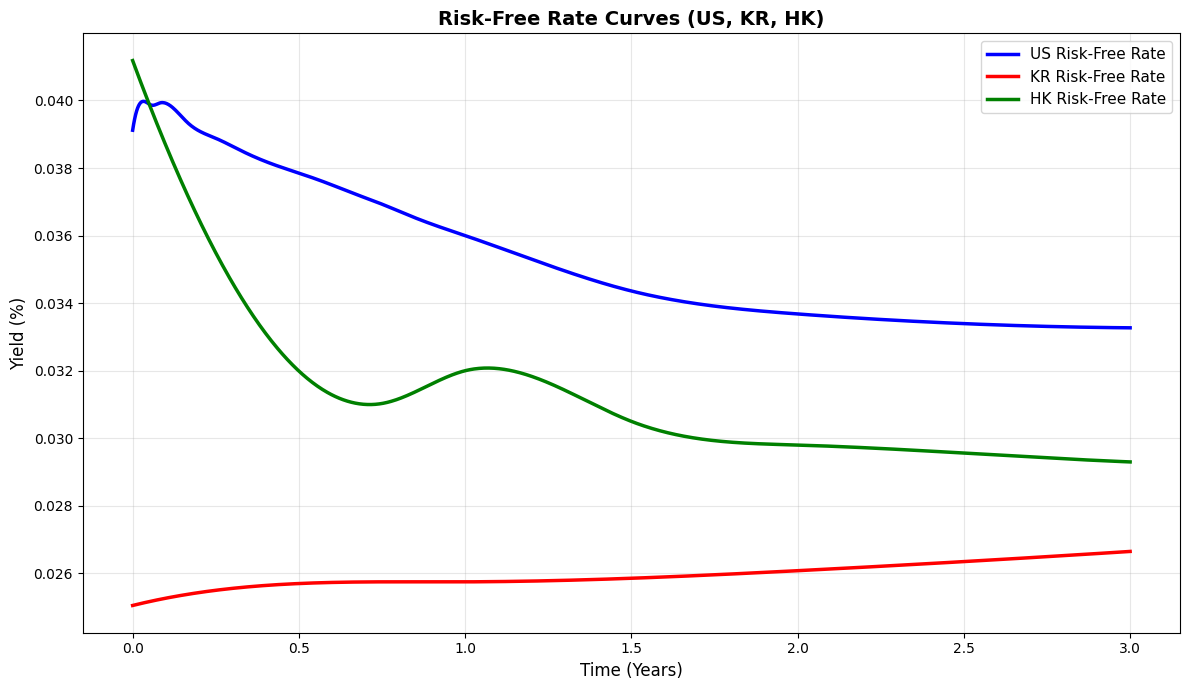

In [21]:
# AI generated plots


plt.figure(figsize=(12, 7))

# Plot all three risk-free rate curves
x = np.linspace(0, 3, 1000)
y_us = us_rf(x)
y_kr = kr_rf(x)
y_hk = hk_rf(x)

plt.plot(x, y_us, linewidth=2.5, label='US Risk-Free Rate', color='blue')
plt.plot(x, y_kr, linewidth=2.5, label='KR Risk-Free Rate', color='red')
plt.plot(x, y_hk, linewidth=2.5, label='HK Risk-Free Rate', color='green')

plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title('Risk-Free Rate Curves (US, KR, HK)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

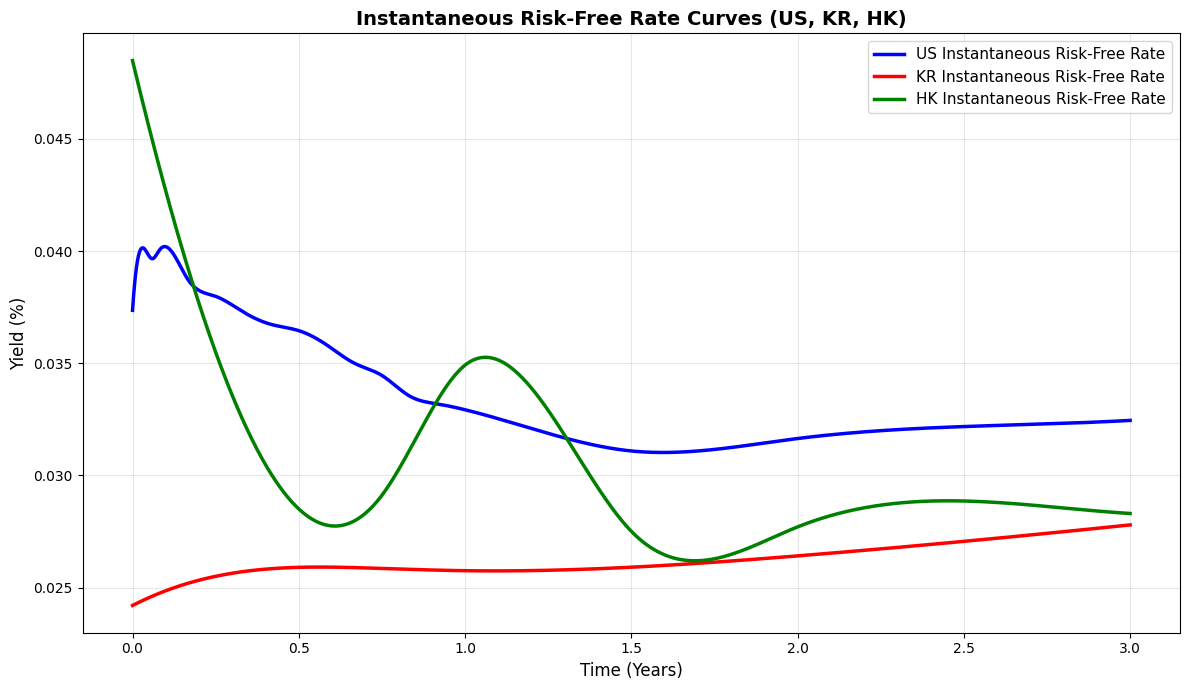

In [47]:
# AI generated plots


plt.figure(figsize=(12, 7))

# Plot all three instantaneous risk-free rate curves
x = np.linspace(0, 3, 1000)
y_us = us_rf.instant(x)
y_kr = kr_rf.instant(x)
y_hk = hk_rf.instant(x)

plt.plot(x, y_us, linewidth=2.5, label='US Instantaneous Risk-Free Rate', color='blue')
plt.plot(x, y_kr, linewidth=2.5, label='KR Instantaneous Risk-Free Rate', color='red')
plt.plot(x, y_hk, linewidth=2.5, label='HK Instantaneous Risk-Free Rate', color='green')

plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title('Instantaneous Risk-Free Rate Curves (US, KR, HK)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

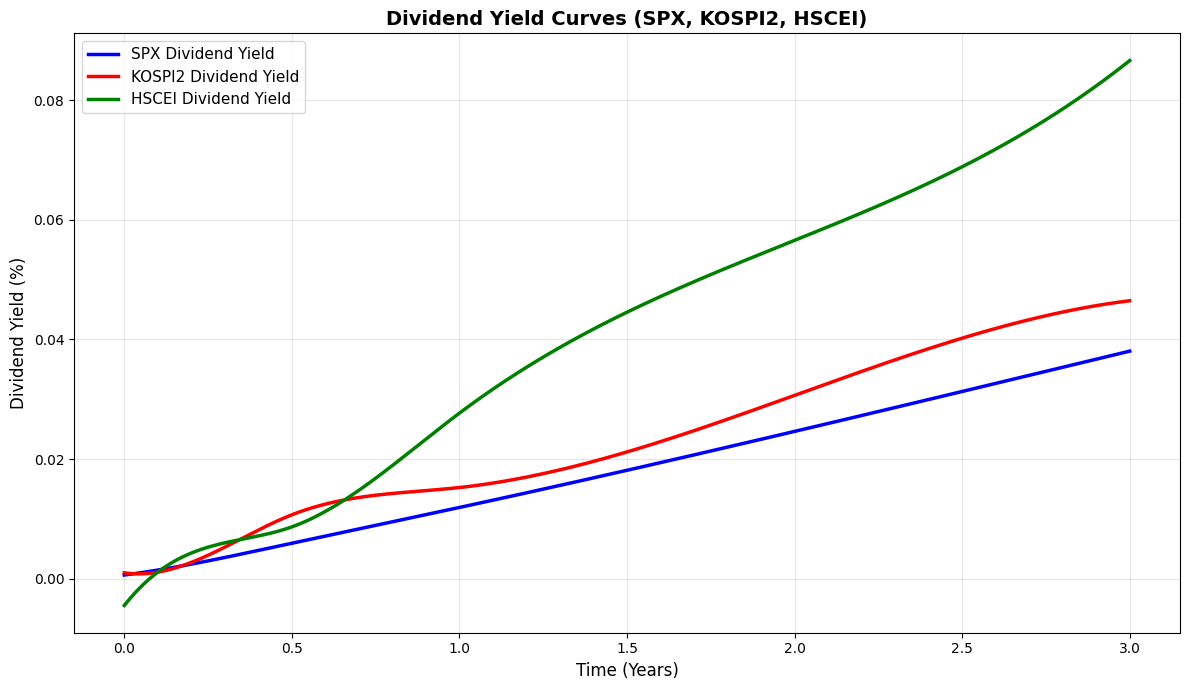

In [23]:
# AI generated plots

plt.figure(figsize=(12, 7))

# Plot all three dividend yield curves
x = np.linspace(0, 3, 1000)
y_spx = spx_div(x)
y_kospi2 = kospi2_div(x)
y_hscei = hscei_div(x)

plt.plot(x, y_spx, linewidth=2.5, label='SPX Dividend Yield', color='blue')
plt.plot(x, y_kospi2, linewidth=2.5, label='KOSPI2 Dividend Yield', color='red')
plt.plot(x, y_hscei, linewidth=2.5, label='HSCEI Dividend Yield', color='green')

plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Dividend Yield (%)', fontsize=12)
plt.title('Dividend Yield Curves (SPX, KOSPI2, HSCEI)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

In [24]:
b = Barrier(x=[0, 1.0, 1.5, 2.0, 2.5, 3.0], y=[130, 125, 120, 115, 110, 105], cont=True)



In [25]:
b(0.3, 137)

True

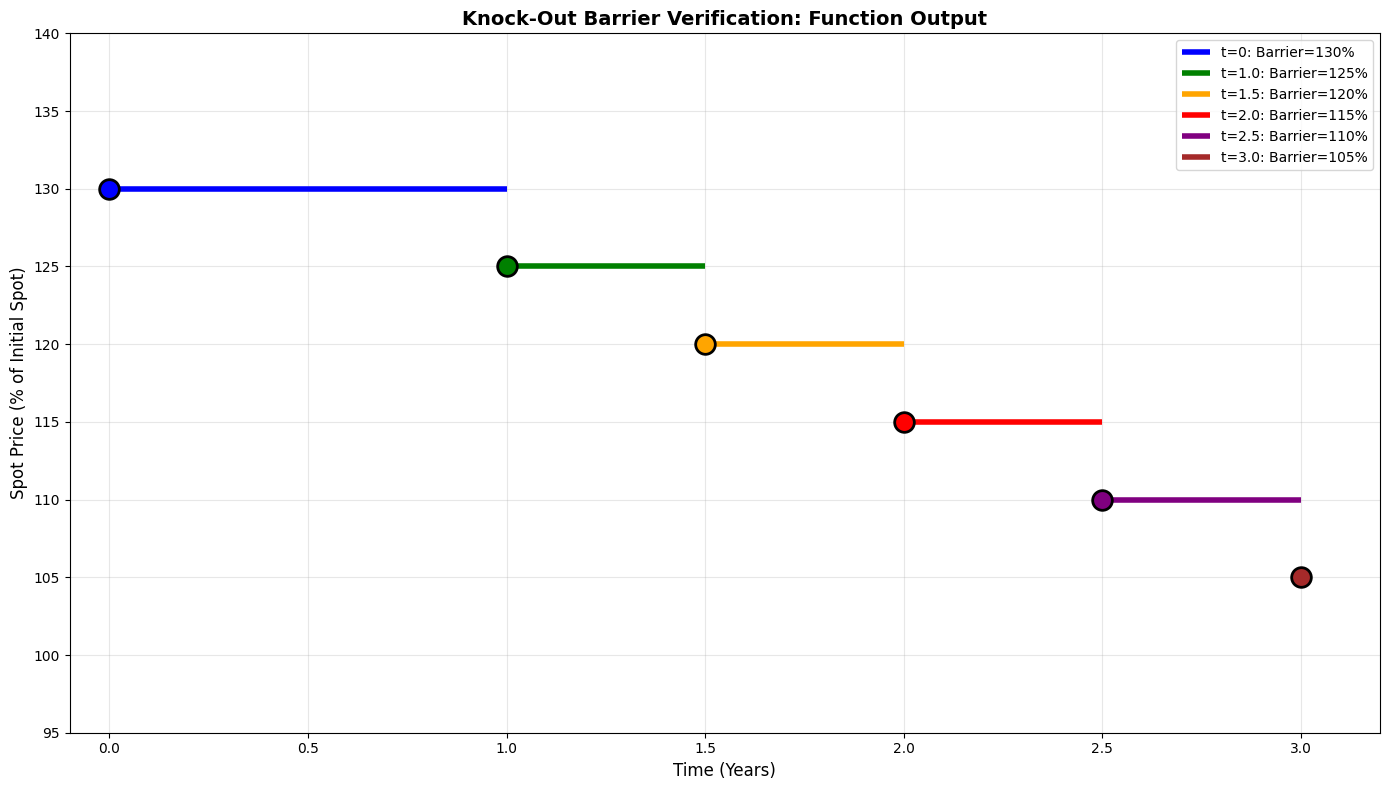


=== Barrier Verification Table ===
Time     Barrier Level   Test Spot=110   Test Spot=125  
-----------------------------------------------------
0.0      130.0           False           False          
1.0      125.0           False           True           
1.5      120.0           False           True           
2.0      115.0           False           True           
2.5      110.0           True            True           
3.0      105.0           True            True           


In [26]:
plt.figure(figsize=(14, 8))

# Test the barrier function at different spot prices and time points
spot_prices = np.linspace(50, 150, 100)

# Plot horizontal step function showing barrier at each time period
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']
for i in range(len(b.x)):
    current_time = b.x[i]
    current_barrier = b.y[i]
    
    # Determine the next time point (or end at maturity)
    if i < len(b.x) - 1:
        next_time = b.x[i + 1]
    else:
        next_time = 3.0
    
    # Draw horizontal line at barrier level from current_time to next_time
    plt.hlines(current_barrier, current_time, next_time, colors=colors[i], linewidth=4, label=f't={current_time}: Barrier={current_barrier}%')
    plt.scatter([current_time], [current_barrier], color=colors[i], s=200, marker='o', zorder=5, edgecolors='black', linewidth=2)

plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Spot Price (% of Initial Spot)', fontsize=12)
plt.title('Knock-Out Barrier Verification: Function Output', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='best')
plt.xlim(-0.1, 3.2)
plt.ylim(95, 140)
plt.tight_layout()
plt.show()

# Print verification table
print("\n=== Barrier Verification Table ===")
print(f"{'Time':<8} {'Barrier Level':<15} {'Test Spot=110':<15} {'Test Spot=125':<15}")
print("-" * 53)
for t in b.x:
    trigger_110 = b(t, 110)
    trigger_125 = b(t, 125)
    barrier_level = b.y[list(b.x).index(t)]
    
    print(f"{t:<8.1f} {barrier_level:<15.1f} {str(trigger_110):<15} {str(trigger_125):<15}")

In [27]:
b = Barrier(x=[0, 1.0, 1.5, 2.0, 2.5, 3.0], y=[130, 125, 120, 115, 110, 105], cont=False)

b(1.1, 126)

False


Loading SPX    | spx_chain/spx_call_2025_12_19.csv | T = 0.132y ... 
Loading SPX    | spx_chain/spx_put_2025_12_19.csv | T = 0.132y ...   377 points → FITTED ATM 6.83% | skew -0.174

Loading SPX    | spx_chain/spx_call_2026_06_18.csv | T = 0.627y ... 
Loading SPX    | spx_chain/spx_put_2026_06_18.csv | T = 0.627y ...   129 points → FITTED ATM 5.32% | skew -0.064

Loading SPX    | spx_chain/spx_call_2026_12_18.csv | T = 1.129y ... 
Loading SPX    | spx_chain/spx_put_2026_12_18.csv | T = 1.129y ...   127 points → FITTED ATM 6.83% | skew -0.174

Loading SPX    | spx_chain/spx_call_2026_06_18.csv | T = 0.627y ... 
Loading SPX    | spx_chain/spx_put_2026_06_18.csv | T = 0.627y ...   129 points → FITTED ATM 5.32% | skew -0.064

Loading SPX    | spx_chain/spx_call_2026_12_18.csv | T = 1.129y ... 
Loading SPX    | spx_chain/spx_put_2026_12_18.csv | T = 1.129y ...   127 points → FITTED ATM 4.80% | skew -0.035

Loading SPX    | spx_chain/spx_call_2027_12_17.csv | T = 1.625y ... 
Loading SPX    

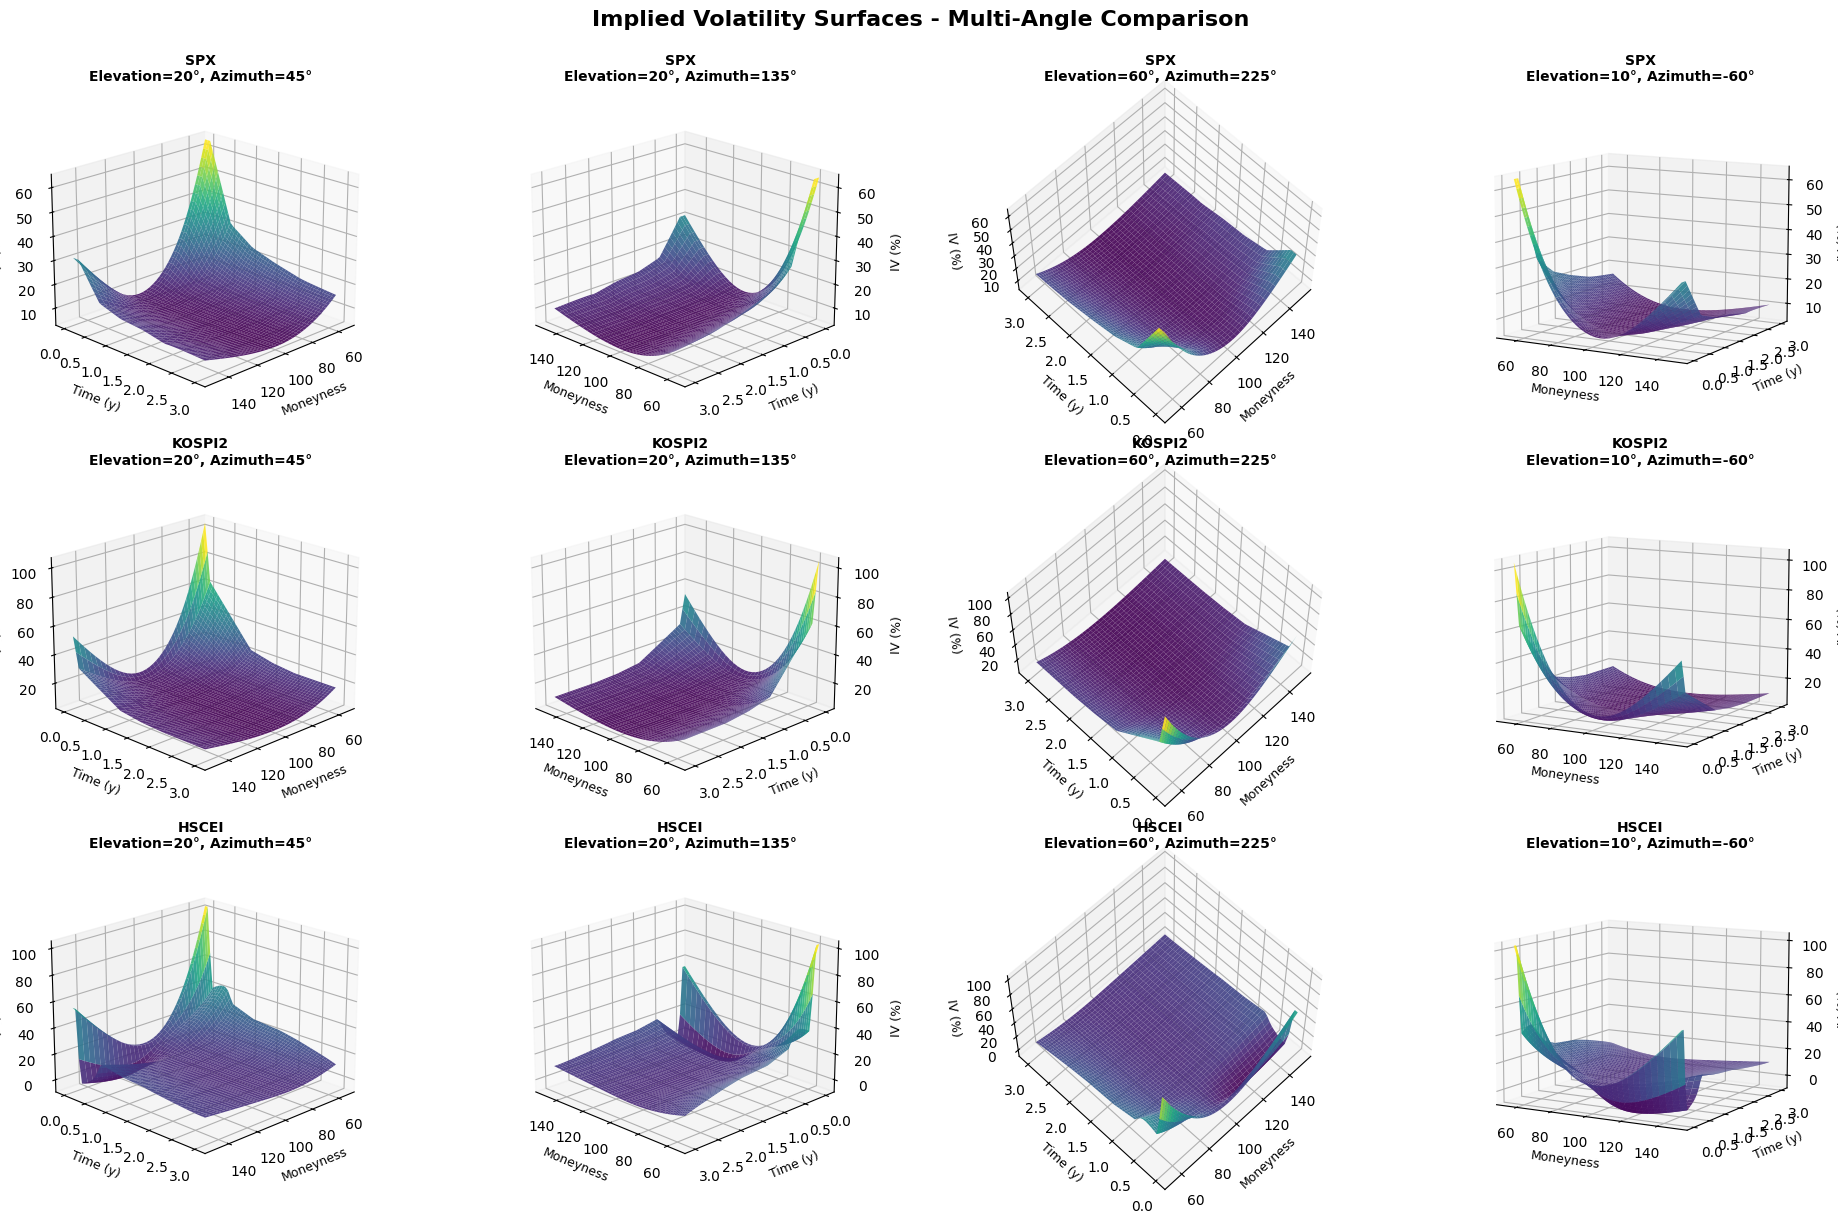

Multi-angle IV surface visualization complete!


In [106]:
#Spot as of 
S0_SPX    = 6840.20
S0_KOSPI2 = 579.46
S0_HSCEI  = 9168.58


spx_files = {
    ('spx_chain/spx_call_2025_12_19.csv', 'spx_chain/spx_put_2025_12_19.csv'): (datetime.date(2025, 12, 19) - datetime.date(2025, 11, 1)).days / 365,
    ('spx_chain/spx_call_2026_06_18.csv', 'spx_chain/spx_put_2026_06_18.csv'): (datetime.date(2026,  6, 18) - datetime.date(2025, 11, 1)).days / 365,
    ('spx_chain/spx_call_2026_12_18.csv', 'spx_chain/spx_put_2026_12_18.csv'): (datetime.date(2026, 12, 18) - datetime.date(2025, 11, 1)).days / 365,
    ('spx_chain/spx_call_2027_12_17.csv', 'spx_chain/spx_put_2027_06_17.csv'): (datetime.date(2027,  6, 17) - datetime.date(2025, 11, 1)).days / 365,
    ('spx_chain/spx_call_2027_06_17.csv', 'spx_chain/spx_put_2027_12_17.csv'): (datetime.date(2027, 12, 17) - datetime.date(2025, 11, 1)).days / 365,
    ('spx_chain/spx_call_2028_12_15.csv', 'spx_chain/spx_put_2028_12_15.csv'): (datetime.date(2028, 12, 15) - datetime.date(2025, 11, 1)).days / 365,
}

kospi2_files = {
    ('kospi2_chain/kospi2_call_2025_11_13.csv', 'kospi2_chain/kospi2_put_2025_11_13.csv'): (datetime.date(2025, 11, 13) - datetime.date(2025, 11, 1)).days / 365,
    ('kospi2_chain/kospi2_call_2025_12_11.csv', 'kospi2_chain/kospi2_put_2025_12_11.csv'): (datetime.date(2025, 12, 11) - datetime.date(2025, 11, 1)).days / 365,
    ('kospi2_chain/kospi2_call_2026_12_10.csv', 'kospi2_chain/kospi2_put_2026_12_10.csv'): (datetime.date(2026, 12, 10) - datetime.date(2025, 11, 1)).days / 365,
    ('kospi2_chain/kospi2_call_2027_06_10.csv', 'kospi2_chain/kospi2_put_2027_06_10.csv'): (datetime.date(2027,  6, 10) - datetime.date(2025, 11, 1)).days / 365,
    ('kospi2_chain/kospi2_call_2027_12_09.csv', 'kospi2_chain/kospi2_put_2027_12_09.csv'): (datetime.date(2027, 12,  9) - datetime.date(2025, 11, 1)).days / 365,
}

hscei_files = {
    ('hscei_chain/hscei_call_2025_11_27.csv', 'hscei_chain/hscei_put_2025_11_27.csv'): (datetime.date(2025,11,27) - datetime.date(2025,11,1)).days / 365,
    ('hscei_chain/hscei_call_2025_12_30.csv', 'hscei_chain/hscei_put_2025_12_30.csv'): (datetime.date(2025,12,30) - datetime.date(2025,11,1)).days / 365, 
    ('hscei_chain/hscei_call_2026_06_29.csv', 'hscei_chain/hscei_put_2026_06_29.csv'): (datetime.date(2026, 6,29) - datetime.date(2025,11,1)).days / 365,
    ('hscei_chain/hscei_call_2026_12_30.csv', 'hscei_chain/hscei_put_2026_12_30.csv'): (datetime.date(2026,12,30) - datetime.date(2025,11,1)).days / 365,
    ('hscei_chain/hscei_call_2027_06_29.csv', 'hscei_chain/hscei_put_2027_06_29.csv'): (datetime.date(2027, 6,29) - datetime.date(2025,11,1)).days / 365,
    ('hscei_chain/hscei_call_2027_12_30.csv', 'hscei_chain/hscei_put_2027_12_30.csv'): (datetime.date(2027,12,30) - datetime.date(2025,11,1)).days / 365,
    ('hscei_chain/hscei_call_2028_12_28.csv', 'hscei_chain/hscei_put_2028_12_28.csv'): (datetime.date(2028,12,28) - datetime.date(2025,11,1)).days / 365,
}




# Build surfaces
spx_surf    = VolatilitySurface('SPX',    S0_SPX,    us_rf,    spx_div,    spx_files, 100)
kospi_surf  = VolatilitySurface('KOSPI2', S0_KOSPI2, kr_rf, kospi2_div, kospi2_files, 250)
hscei_surf  = VolatilitySurface('HSCEI',  S0_HSCEI,  hk_rf,  hscei_div,  hscei_files,  50)

# =============================================
# 3D VOLATILITY SURFACES - ALTERNATIVE VIEWING ANGLES
# =============================================

fig = plt.figure(figsize=(20, 12))

# Define multiple viewing angles for comprehensive visualization
angles = [
    (20, 45),      # View 1: Standard front
    (20, 135),     # View 2: Left side
    (60, 225),     # View 3: Top-down
    (10, -60),     # View 4: Back angle
]
angle_labels = [
    "Elevation=20°, Azimuth=45°",
    "Elevation=20°, Azimuth=135°",
    "Elevation=60°, Azimuth=225°",
    "Elevation=10°, Azimuth=-60°"
]

# Helper to generate surface data
def get_surface_data(vol_surface):
    moneyness = np.linspace(-0.6, 0.4, 40)
    times = np.linspace(0.01, 3, 50)
    M, T = np.meshgrid(moneyness, times)
    IV = np.vectorize(vol_surface.implied_vol)(M, T)
    moneyness_pct = np.exp(M) * 100
    return moneyness_pct, T, IV

# SPX - Multiple angles
print("Generating SPX surface from multiple viewing angles...")
spx_data = get_surface_data(spx_surf)

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(3, 4, idx + 1, projection='3d')
    M, T, IV = spx_data
    surf = ax.plot_surface(M, T, IV*100, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_xlabel('Moneyness', fontsize=9)
    ax.set_ylabel('Time (y)', fontsize=9)
    ax.set_zlabel('IV (%)', fontsize=9)
    ax.set_title(f'SPX\n{angle_labels[idx]}', fontsize=10, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)

# KOSPI2 - Multiple angles
print("Generating KOSPI2 surface from multiple viewing angles...")
kospi_data = get_surface_data(kospi_surf)

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(3, 4, idx + 5, projection='3d')
    M, T, IV = kospi_data
    surf = ax.plot_surface(M, T, IV*100, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_xlabel('Moneyness', fontsize=9)
    ax.set_ylabel('Time (y)', fontsize=9)
    ax.set_zlabel('IV (%)', fontsize=9)
    ax.set_title(f'KOSPI2\n{angle_labels[idx]}', fontsize=10, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)

# HSCEI - Multiple angles
print("Generating HSCEI surface from multiple viewing angles...")
hscei_data = get_surface_data(hscei_surf)

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(3, 4, idx + 9, projection='3d')
    M, T, IV = hscei_data
    surf = ax.plot_surface(M, T, IV*100, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_xlabel('Moneyness', fontsize=9)
    ax.set_ylabel('Time (y)', fontsize=9)
    ax.set_zlabel('IV (%)', fontsize=9)
    ax.set_title(f'HSCEI\n{angle_labels[idx]}', fontsize=10, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)

plt.suptitle('Implied Volatility Surfaces - Multi-Angle Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Multi-angle IV surface visualization complete!")